# Immune Dynamics and Transcriptional Remodeling Following PD-1 Blockade (Figure 4)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure 4a–h** and **Table 7** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to investigate the longitudinal changes in the tumor immune microenvironment and the functional reprogramming of T and NK cells in response to PD-1 blockade therapy. Specifically, we:
1.  Quantify the shifts in the cellular composition of major immune lineages and specific T/NK subsets pre- and post-Immune Checkpoint Inhibitor (ICI) treatment.
2.  Assess the differential abundance of cell neighborhoods (Nhoods) and the modulation of key gene expression programs—specifically cytotoxicity, exhaustion, inflammation, and stress—across selected subsets following therapy.
3.  Identify context-specific gene expression changes in distinct T cell populations (Th, Tregs, Tex, NKT) by analyzing the intersection of "cell type specificity" and "therapy response."
4.  Perform pathway enrichment analysis to reveal the biological processes and HallMark gene sets that are significantly altered in key exhausted and regulatory populations after ICI treatment.

In [798]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import os
import seaborn as sns
from scipy.sparse import csc_matrix, csr_matrix
from collections import Counter
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [ ]:
figPath = "./figures/fig4"
tablePath = "./tables"
irPath = "./data/NKTCL-ir.h5ad"
TPath = './data/NKTCL_T.h5ad'
CD8TPath = './data/NKTCL_CD8T.h5ad'
CD4TPath = './data/NKTCL_CD4T.h5ad'
NKPath = './data/NKTCL_NK.h5ad'
TprolPath = './data/NKTCL_Tprol.h5ad'
# Check if the directory exists, if not, create it (including parent directories if necessary)
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_T = sc.read_h5ad(TPath)
adata_NK = sc.read_h5ad(NKPath)
adata_Tprol = sc.read_h5ad(TprolPath)
adata_CD8T = sc.read_h5ad(CD8TPath)
adata_CD4T = sc.read_h5ad(CD4TPath)

#### **Fig. 4a** Box plots show the changes in the proportions of major immune cell lineages and detailed T/NK cell subsets before and after ICI. 
All proportions were calculated as the percentage of the total non-malignant T and NK cell pool. The central line represents the median, box limits indicate the interquartile range (IQR), and whiskers extend to 1.5× IQR. Statistical significance was assessed using the Mann-Whitney U test. P-values < 0.05 were considered statistically significant.

In [ ]:
def concat(adata1:ad.AnnData, adata2:ad.AnnData):
    '''
    This function merges two AnnData objects by first preserving their original batch information 
    in a temporary 'sample' column, performing the concatenation, and then standardizing the batch metadata. 
    It also cleans up the cell observation names by truncating the suffix and removes the temporary column
    before returning the combined dataset.
    '''
    adata1 = adata1.copy()
    adata2 = adata2.copy()
    adata1.obs['sample'] = adata1.obs['batch']
    adata2.obs['sample'] = adata2.obs['batch']
    adata_concat = adata1.concatenate(adata2)
    adata_concat.obs['batch'] = adata_concat.obs['sample']
    adata_concat.obs_names = [s[:-2] for s in adata_concat.obs_names]
    del adata_concat.obs['sample']
    return adata_concat

In [ ]:
# ---------------------------------------------------------
# Construct a reference "Normal Immune" atlas
# ---------------------------------------------------------
# This section defines and combines specific non-malignant 
# immune populations to create a baseline reference atlas. 
# It selects normal NK subsets (FGFBP2+ and KIT+), proliferating 
# T cells (MKI67+), and normal T cells (excluding malignant, 
# NKT-like, and mixed clusters). These subsets are then 
# sequentially merged using the concat function to form the 
# integrated 'norm_immune' object.
# ---------------------------------------------------------
norm_NK = adata_NK[adata_NK.obs['CellStateLabels'].isin(['NK06: Norm_FGFBP2','NK07: Norm_KIT'])]
norm_Tprol = adata_Tprol[adata_Tprol.obs['Tprol_status'].isin(['T12: Tprol_MKI67'])]
norm_T = adata_T[~adata_T.obs['CellStateLabels'].isin(['T12: Tprol_MKI67','T13: Malig_MSI2','T14: NK/NKT-like','T15: mixed'])]
norm_immune = concat(norm_NK, norm_Tprol)
norm_immune = concat(norm_immune, norm_T)
norm_immune

/tmp/ipykernel_3335451/18291297.py:6: FutureWarning:

Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html

/tmp/ipykernel_3335451/18291297.py:6: FutureWarning:

Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html



AnnData object with n_obs × n_vars = 45729 × 21906
    obs: 'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'cnv_status', 'cnv_score', 'leiden-T', 'LMP-1', 'leiden-NK', 'leiden-NK1', 'LMP-1.1', 'anno-NK', 'leiden-NK2', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'proliferation', 'inflammatory_score', 'stress_score', 'exhaustion_score', 'cytotoxicity_score', 'EBV', 'anno-fixed', 'anno-cnv', 'anno-cnv-minor', 'anno-cnv1', 'score', 'MHC class I', 'MHC class II', 'novelty_score', 'CellStateLabels', 'exhaustion', 'inflammation', 'stress', 'cytotoxicity', 'anno-standard', 'cnv_leiden', 'Tprol_status', 'clonal_size', 'annotation', 'anno-T', 'spot_size', 'anno-subT', 'anno-Tfixed', 'anno-subTfixed', 'anno-subT1', 'anno-focus'
    var: 'type', 'ID-0-0', 'name-0-0', 'n_cells_by_counts-0-0',

In [ ]:
from scipy.stats import fisher_exact, mannwhitneyu

def compare_cell_type_proportion(
    adata,
    target_label,
    anno_col='anno',
    treatment_col='treatment',
    batch_col='batch',
    pre_label='Pre',
    post_label='Post',
    plot=True,
    figsize=(5, 5),
    title_prefix=None
):
    """
    Compare the proportion of one or more cell types between pre- and post-treatment samples.
    
    Supports:
      - Single cell type (e.g., 'C08_Treg_FOXP3')
      - Multiple cell types combined (e.g., ['C08_Treg_FOXP3', 'C09_Treg_IL2RA'])
    
    Two statistical approaches:
      1. Cell-level Fisher's exact test (all cells)
      2. Sample-level one-sided Mann-Whitney U test (Post > Pre)

    Parameters:
    ----------
    adata : AnnData
        Single-cell data object with .obs metadata.
    target_label : str or list of str
        Cell type label(s) in anno_col to analyze. If list, proportions are summed.
    anno_col : str
        Column name for cell type annotation (default: 'anno').
    treatment_col : str
        Column name for treatment status (default: 'treatment').
    batch_col : str
        Column name for sample/batch ID (default: 'batch').
    pre_label : str
        Label for pre-treatment group (default: 'Pre').
    post_label : str
        Label for post-treatment group (default: 'Post').
    plot : bool
        Whether to generate a sample-level proportion plot (default: True).
    figsize : tuple
        Figure size (default: (5, 5)).
    title_prefix : str or None
        Custom title prefix. If None, auto-generated from target_label.

    Returns:
    -------
    dict : Dictionary with cell-level and sample-level results.
    """
    # === Normalize target_label to list ===
    if isinstance(target_label, str):
        target_labels = [target_label]
        label_display = target_label
    elif isinstance(target_label, (list, tuple)):
        target_labels = list(target_label)
        if len(target_labels) == 1:
            label_display = target_labels[0]
        else:
            label_display = f"{' + '.join(target_labels)} (combined)"
    else:
        raise ValueError("`target_label` must be a string or a list/tuple of strings.")
    
    # === Validate columns ===
    required_cols = [anno_col, treatment_col, batch_col]
    missing_cols = [col for col in required_cols if col not in adata.obs.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in adata.obs: {missing_cols}")
    
    df = adata.obs[required_cols].copy()
    df = df[df[treatment_col].isin([pre_label, post_label])].copy()
    
    if df.empty:
        raise ValueError("No samples found with the specified treatment labels.")
    
    # Identify cells belonging to any of the target types
    df['is_target'] = df[anno_col].isin(target_labels).astype(int)
    
    # === Step 1: Cell-level Fisher's exact test ===
    contingency = pd.crosstab(df[treatment_col], df['is_target'])
    for col in [0, 1]:
        if col not in contingency.columns:
            contingency[col] = 0
    contingency = contingency[[0, 1]]
    contingency.columns = ['Non-Target', 'Target']
    contingency.index.name = 'Treatment'

    odds_ratio, p_fisher = fisher_exact(contingency.values, alternative='two-sided')
    
    total_pre = contingency.loc[pre_label].sum()
    total_post = contingency.loc[post_label].sum()
    prop_pre_cell = contingency.loc[pre_label, 'Target'] / total_pre if total_pre > 0 else 0
    prop_post_cell = contingency.loc[post_label, 'Target'] / total_post if total_post > 0 else 0

    print("=== Cell-level Analysis (All Cells) ===")
    print(f"Target cell type(s): {label_display}")
    print(contingency)
    print(f"\nFisher's exact test p-value: {p_fisher:.3e}")
    print(f"Proportion - {pre_label}: {prop_pre_cell:.1%}, {post_label}: {prop_post_cell:.1%}\n")

    # === Step 2: Sample-level analysis ===
    summary_rows = []
    for batch_name, sub in df.groupby(batch_col):
        if len(sub) == 0:
            continue
        treatment_val = sub[treatment_col].iloc[0]
        if treatment_val not in [pre_label, post_label]:
            continue
        prop = sub['is_target'].mean()
        summary_rows.append({
            'batch': batch_name,
            'treatment': treatment_val,
            'prop_target': prop
        })
    
    if not summary_rows:
        raise ValueError("No valid batches found for sample-level analysis.")
    
    sample_df = pd.DataFrame(summary_rows)
    pre_props = sample_df[sample_df['treatment'] == pre_label]['prop_target'].values
    post_props = sample_df[sample_df['treatment'] == post_label]['prop_target'].values

    if len(pre_props) == 0 or len(post_props) == 0:
        raise ValueError("Missing Pre or Post group in sample-level data.")

    # One-sided Mann-Whitney U test (Post > Pre)
    u_stat, p_mwu_one_sided = mannwhitneyu(post_props, pre_props, alternative='greater')
    
    mean_pre = np.mean(pre_props)
    mean_post = np.mean(post_props)
    median_pre = np.median(pre_props)
    median_post = np.median(post_props)

    print("=== Sample-level Analysis (Per Sample) ===")
    print(f"Number of samples: {pre_label} = {len(pre_props)}, {post_label} = {len(post_props)}")
    print(f"Mean proportion - {pre_label}: {mean_pre:.1%}, {post_label}: {mean_post:.1%}")
    print(f"Median proportion - {pre_label}: {median_pre:.1%}, {post_label}: {median_post:.1%}")
    print(f"Mann-Whitney U test (one-sided, {post_label} > {pre_label}): p = {p_mwu_one_sided:.3f}\n")

    # === Step 3: Visualization ===
    if plot:
        title = title_prefix or label_display
        plt.figure(figsize=figsize)
        sns.stripplot(
            data=sample_df,
            x='treatment',
            y='prop_target',
            order=[pre_label, post_label],
            size=6,
            palette=['lightblue', 'salmon']
        )
        plt.ylabel('Proportion')
        plt.xlabel('Treatment Group')
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return {
        'target_labels': target_labels,
        'cell_level': {
            'contingency_table': contingency,
            'p_fisher': p_fisher,
            'prop_pre': prop_pre_cell,
            'prop_post': prop_post_cell
        },
        'sample_level': {
            'n_pre': len(pre_props),
            'n_post': len(post_props),
            'mean_pre': mean_pre,
            'mean_post': mean_post,
            'median_pre': median_pre,
            'median_post': median_post,
            'p_mwu_one_sided': p_mwu_one_sided,
            'u_stat': u_stat,
            'pre_props': pre_props,
            'post_props': post_props
        },
        'summary_df': sample_df
    }

In [805]:
# ---------------------------------------------------------
# Annotate cell clusters based on a mapping dictionary
# ---------------------------------------------------------
# This function assigns biological labels (e.g., cell types) 
# to cells in an AnnData object. It maps specific cluster IDs 
# (from a leiden clustering column) to user-defined annotations 
# based on a provided dictionary, overwriting any existing 
# annotations in the specified observation key.
# ---------------------------------------------------------

def anno(adata:ad.AnnData, annoDict:dict, obsKey='cnv_status', obsVal='cnv_leiden', default="Unknown"):
  if default is not None:
    adata.obs[obsKey] = default
  for key in annoDict.keys():
    adata.obs.loc[adata.obs[obsVal].isin(annoDict[key]), obsKey] = key
  return adata

In [806]:
annot = {
  'Normal NK': ['NK06: Norm_FGFBP2', 'NK07: Norm_KIT'],
  'CD8+ T': ['T01: Tn_CCR7', 'T02: Tcm_SELL',
       'T03: Tcm_XCL1', 'T04: Trm_ZNF683', 'T05: pTex_CD39', 'T06: Tex_CD8',
       ],
  'CD4+ T': ['T07: Tex_CD4', 'T08: Treg_FOXP3', 'T09: Th_CXCL13', 'T10: Tn/Tcm_IL7R',
       'T11: Tctl_GZMK'],
  'Proliferating T': ['T12: Tprol_MKI67'],
}
norm_immune = anno(norm_immune, annot, 'CellTypeLabels', 'CellStateLabels')
norm_immune.obs['CellTypeLabels'] = norm_immune.obs['CellTypeLabels'].astype('category')

In [ ]:
results = {}
results_keys = list(norm_immune.obs['CellTypeLabels'].cat.categories)
for key in results_keys:
    results[key] = compare_cell_type_proportion(norm_immune, key, 'CellTypeLabels', plot=False)

/tmp/ipykernel_3335451/96303025.py:9: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_3335451/96303025.py:63: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CD8+ T_Pre vs. CD8+ T_Post: ns
CD4+ T_Pre vs. CD4+ T_Post: ns
Normal NK_Pre vs. Normal NK_Post: ns
Proliferating T_Pre vs. Proliferating T_Post: ns


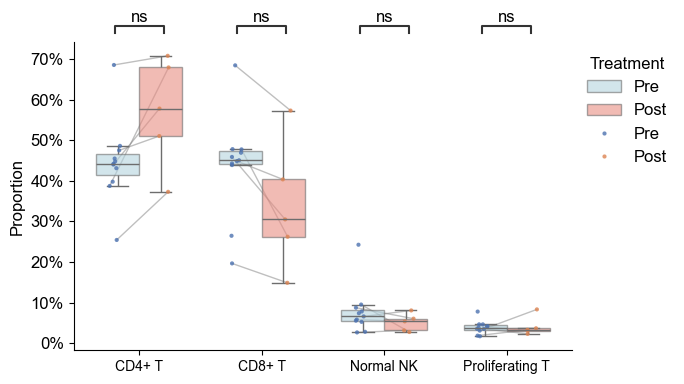

In [811]:
from statannotations.Annotator import Annotator

# --- 1. Data preparation ---
df = pd.DataFrame(columns=['batch', 'treatment' , 'prop_target', 'celltype'])
for key in results.keys():
  _df = results[key]['summary_df'].copy()
  _df['celltype'] = key
  _df.columns = ['batch', 'treatment' , 'prop_target', 'celltype']
  df = pd.concat([df, _df])
df['patient_id'] = df['batch'].str.extract(r'([A-Za-z0-9]+)_\d+')

# --- 2. draw box plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 4)) 
box_colors = ['lightblue', 'salmon']
dot_colors = ['#4c72b0', '#dd8452']

sns.boxplot(
  data=df,
  x='celltype',
  y='prop_target',
  hue='treatment',
  ax=ax,
  boxprops=dict(alpha=0.6),
  width=0.7,
  showfliers=False, 
  palette=box_colors
)
sns.stripplot(
    data=df,
    x='celltype',
    y='prop_target',
    hue='treatment',
    ax=ax,
    palette=dot_colors, 
    size=3,                          
    alpha=0.8,                      
    dodge=True,    
    jitter=True,                  
    zorder=2                         
)
x_labels = ax.get_xticklabels()
x_positions = ax.get_xticks()
for i, celltype in enumerate(x_labels):
    dots_pre = ax.collections[i*2]
    dots_post = ax.collections[i*2+1]
    paths_pre = dots_pre.get_offsets()
    paths_post = dots_post.get_offsets()
    celltype = celltype.get_text()
    cell_df = df[df['celltype'] == celltype]
    pre_df = cell_df[cell_df['treatment'] == 'Pre'].reset_index(drop=True)
    post_df = cell_df[cell_df['treatment'] == 'Post'].reset_index(drop=True)
    grouped = cell_df.groupby('patient_id')
    for patient_id, group in grouped:
        if len(group) == 2:
            pre_idx_in_group = pre_df[pre_df['patient_id'] == patient_id].index[0]
            post_idx_in_group = post_df[post_df['patient_id'] == patient_id].index[0]
            x1, y1 = paths_pre[pre_idx_in_group]
            x2, y2 = paths_post[post_idx_in_group]
            ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.5, lw=1, zorder=0)
        

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Treatment', frameon=False)

# --- 3. Define P-value ---
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    else:
        return "ns"

pairs = []
annotations = []

for key in results.keys():
    pairs.append( ((key, 'Pre'), (key, 'Post')) )
    p_val = results[key]['sample_level']['p_mwu_one_sided']
    annotations.append(convert_pvalue_to_asterisks(p_val))
annotator = Annotator(ax, pairs, data=df, x='celltype', y='prop_target', hue='treatment')
annotator.configure(test=None, text_format='star', loc='outside') 
annotator.annotate_custom_annotations(annotations)
plt.tight_layout()
fig.savefig(f"{figPath}/Fig4a-type.pdf", bbox_inches='tight')
plt.show()

In [ ]:
results = {}
results_keys = list(norm_immune.obs['CellStateLabels'].cat.categories)
for key in results_keys:
    results[key] = compare_cell_type_proportion(norm_immune, key, 'CellStateLabels', plot=False)

/tmp/ipykernel_3335451/3745118123.py:9: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_3335451/3745118123.py:63: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

T08: Treg_FOXP3_Pre vs. T08: Treg_FOXP3_Post: ns
T09: Th_CXCL13_Pre vs. T09: Th_CXCL13_Post: *
T10: Tn/Tcm_IL7R_Pre vs. T10: Tn/Tcm_IL7R_Post: ns
T11: Tctl_GZMK_Pre vs. T11: Tctl_GZMK_Post: ns
T12: Tprol_MKI67_Pre vs. T12: Tprol_MKI67_Post: ns
T07: Tex_CD4_Pre vs. T07: Tex_CD4_Post: ns
NK07: Norm_KIT_Pre vs. NK07: Norm_KIT_Post: ns
NK06: Norm_FGFBP2_Pre vs. NK06: Norm_FGFBP2_Post: ns
T01: Tn_CCR7_Pre vs. T01: Tn_CCR7_Post: ns
T02: Tcm_SELL_Pre vs. T02: Tcm_SELL_Post: ns
T03: Tcm_XCL1_Pre vs. T03: Tcm_XCL1_Post: ns
T04: Trm_ZNF683_Pre vs. T04: Trm_ZNF683_Post: ns
T05: pTex_CD39_Pre vs. T05: pTex_CD39_Post: ns
T06: Tex_CD8_Pre vs. T06: Tex_CD8_Post: ns


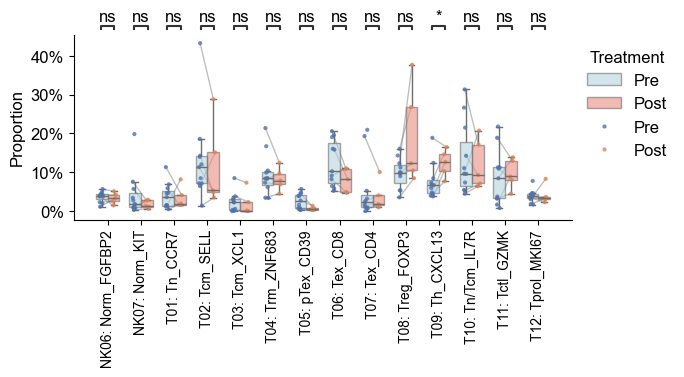

In [808]:
from statannotations.Annotator import Annotator

# --- 1. Data preparation ---
df = pd.DataFrame(columns=['batch', 'treatment' , 'prop_target', 'celltype'])
for key in results.keys():
  _df = results[key]['summary_df'].copy()
  _df['celltype'] = key
  _df.columns = ['batch', 'treatment' , 'prop_target', 'celltype']
  df = pd.concat([df, _df])
df['patient_id'] = df['batch'].str.extract(r'([A-Za-z0-9]+)_\d+')

# --- 2. draw box plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 4)) 
box_colors = ['lightblue', 'salmon']
dot_colors = ['#4c72b0', '#dd8452']

sns.boxplot(
  data=df,
  x='celltype',
  y='prop_target',
  hue='treatment',
  ax=ax,
  boxprops=dict(alpha=0.6),
  width=0.7,
  showfliers=False, 
  palette=box_colors
)
sns.stripplot(
    data=df,
    x='celltype',
    y='prop_target',
    hue='treatment',
    ax=ax,
    palette=dot_colors, 
    size=3,                          
    alpha=0.8,                      
    dodge=True,    
    jitter=True,                  
    zorder=2                         
)
x_labels = ax.get_xticklabels()
x_positions = ax.get_xticks()
for i, celltype in enumerate(x_labels):
    dots_pre = ax.collections[i*2]
    dots_post = ax.collections[i*2+1]
    paths_pre = dots_pre.get_offsets()
    paths_post = dots_post.get_offsets()
    celltype = celltype.get_text()
    cell_df = df[df['celltype'] == celltype]
    pre_df = cell_df[cell_df['treatment'] == 'Pre'].reset_index(drop=True)
    post_df = cell_df[cell_df['treatment'] == 'Post'].reset_index(drop=True)
    grouped = cell_df.groupby('patient_id')
    for patient_id, group in grouped:
        if len(group) == 2:
            pre_idx_in_group = pre_df[pre_df['patient_id'] == patient_id].index[0]
            post_idx_in_group = post_df[post_df['patient_id'] == patient_id].index[0]
            x1, y1 = paths_pre[pre_idx_in_group]
            x2, y2 = paths_post[post_idx_in_group]
            ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.5, lw=1, zorder=0)
        

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Treatment', frameon=False)

# --- 3. Define P-value ---
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    else:
        return "ns"

pairs = []
annotations = []

for key in results.keys():
    pairs.append( ((key, 'Pre'), (key, 'Post')) )
    p_val = results[key]['sample_level']['p_mwu_one_sided']
    annotations.append(convert_pvalue_to_asterisks(p_val))
annotator = Annotator(ax, pairs, data=df, x='celltype', y='prop_target', hue='treatment')
annotator.configure(test=None, text_format='star', loc='outside') 
annotator.annotate_custom_annotations(annotations)
plt.tight_layout()
fig.savefig(f"{figPath}/Fig4a-state.pdf", bbox_inches='tight')
plt.show()

#### **Fig. 4b** Bee-swarm plot of the log fold change distribution across pre-ICI (left) and post-ICI (right) samples containing cells from selected T and NK subtypes. 
Neighborhoods in the differential abundance analysis at a spatialFDR of 10% are shown in color.

In [ ]:
import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [ ]:
%load_ext rpy2.ipython
anndata2ri.set_ipython_converter()

In [ ]:
def prepare_miloR(adata:ad.AnnData, conDict:dict, condName, condVal, batch='batch'):
  """
  Prepares data for MiloR differential abundance analysis.
  
  This function processes an AnnData object to create the necessary inputs for MiloR.
  It creates a copy of the data without existing KNN graph information to ensure 
  MiloR builds a fresh graph. It then annotates the data with the specified condition,
  filters for valid categories, and extracts the original connectivity matrix and 
  experimental design metadata.
  
  Parameters:
  -----------
  adata : AnnData
      The input AnnData object containing the single-cell data and existing neighbors graph.
  conDict : dict
      Dictionary used for annotation mapping.
  condName : str
      The name of the condition column to be created/used (e.g., 'group').
  condVal : str
      The value or key used to map conditions from conDict.
  batch : str, optional
      The column name in adata.obs representing batch information (default is 'batch').
      
  Returns:
  --------
  tuple
      A tuple containing:
      - adata_no_knn: The processed AnnData object (without pre-existing graph).
      - knn_adjacency: The connectivity matrix from the original adata.
      - design_df: A DataFrame defining the experimental design (batch vs condition).
  """
  # Create a copy of the data to avoid modifying the original
  adata_no_knn = adata.copy()
  # Remove existing graph information to force MiloR to build a new one
  adata_no_knn.obsp = None
  adata_no_knn.uns.pop("neighbors")
  # Annotate the data with the specified condition
  adata_no_knn = anno(adata_no_knn, annoDict=conDict, obsKey=condName, obsVal=condVal, default=None)
  # Ensure the condition column is categorical
  adata_no_knn.obs[condName] = adata_no_knn.obs[condName].astype('category')
  # Get the valid categories present in the data
  used_cond = adata_no_knn.obs[condName].cat.categories
  # Filter the data to keep only cells belonging to the specified conditions
  adata_no_knn = adata_no_knn[adata_no_knn.obs[condName].isin(used_cond)]  # only use conditions condDict 
  print(adata_no_knn.obs[condName].cat.categories)
  # Extract the connectivity matrix from the original object
  knn_adjacency = adata.obsp["connectivities"]
  # Create the design matrix for MiloR
  design_df = adata_no_knn.obs[[batch,condName]]
  design_df.drop_duplicates(inplace=True)
  design_df.index = design_df['batch']
  return adata_no_knn, knn_adjacency, design_df

In [ ]:
adata_NK1 = adata_NK[adata_NK.obs['batch'].isin(['NK11_0', 'NK11_1','NK5_0', 'NK5_1', 'NK6_0', 'NK6_1', 'NK7_0', 'NK7_1', 'NK8_0', 'NK8_1', 'PB9_0'])]
conDict = {
  'left': ['Pre',],
  'right': ['Post', 'PBMC']
}
adata_no_knn, knn_adjacency, design_df = prepare_miloR(adata_NK1, conDict, 'TorN', 'treatment')

In [ ]:
%%R -i adata_no_knn
library(miloR)
library(igraph)
library(ggplot2)
library(ggbeeswarm)
library(colorspace)
milo <- Milo(adata_no_knn)

In [ ]:
%%R -i knn_adjacency
milo_graph <- buildFromAdjacency(knn_adjacency, k=20, is.binary=TRUE)
graph(milo) <- miloR::graph(milo_graph)

milo <- buildGraph(milo, k=20, d=30)

## Define neighbourhoods
milo <- makeNhoods(milo, prop = 0.1, k = 20, d=30, refined = TRUE)
## Count cells in neighbourhoods
milo <- countCells(milo, meta.data = data.frame(colData(milo)), sample="batch")

## Calculate distances between cells in neighbourhoods
## for spatial FDR correction
milo <- calcNhoodDistance(milo, d=30)

In [ ]:
%%R -i design_df -o DA_NK
## Test for differential abundance
DA_NK <- testNhoods(milo, design = ~ TorN, design.df = design_df)
DA_NK <- annotateNhoods(milo, DA_NK, coldata_col = "CellStateLabels")

In [ ]:
DA_NK.columns = ['logFC', 'logCPM', 'F', 'PValue', 'FDR', 'Nhood', 'SpatialFDR',
                'anno', 'anno_fraction']

In [ ]:
adata_T1 = adata_T[adata_T.obs['batch'].isin(['NK11_0', 'NK11_1','NK5_0', 'NK5_1', 'NK6_0', 'NK6_1', 'NK7_0', 'NK7_1', 'NK8_0', 'NK8_1', 'PB9_0'])]
conDict = {
  'left': ['Pre',],
  'right': ['Post', 'PBMC']
}
adata_no_knn_T, knn_adjacency_T, design_df_T = prepare_miloR(adata_T1, conDict, 'TorN', 'treatment')

In [ ]:
%%R -i adata_no_knn_T
milo_T <- Milo(adata_no_knn_T)

In [ ]:
%%R -i knn_adjacency_T
milo_T <- Milo(adata_no_knn_T)
milo_graph_T <- buildFromAdjacency(knn_adjacency_T, k=20, is.binary=TRUE)
graph(milo_T) <- miloR::graph(milo_graph_T)
milo_T <- buildGraph(milo_T, k=20, d=30)
## Define neighbourhoods
milo_T <- makeNhoods(milo_T, prop = 0.1, k = 20, d=30, refined = TRUE)
## Count cells in neighbourhoods
milo_T <- countCells(milo_T, meta.data = data.frame(colData(milo_T)), sample="batch")

## Calculate distances between cells in neighbourhoods
## for spatial FDR correction
milo_T <- calcNhoodDistance(milo_T, d=30)

In [ ]:
%%R -i design_df_T -o DA_T
DA_T <- testNhoods(milo_T, design = ~ TorN, design.df = design_df_T)
DA_T <- annotateNhoods(milo_T, DA_T, coldata_col = "CellStateLabels")

In [ ]:
DA_T.columns = ['logFC', 'logCPM', 'F', 'PValue', 'FDR', 'Nhood', 'SpatialFDR',
                'anno', 'anno_fraction']
DA_T = pd.DataFrame(DA_T)
DA_T = DA_T[DA_T['CellStateLabels'].isin([ 'T04: Trm_ZNF683','T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4', 'T08: Treg_FOXP3','T09: Th_CXCL13', 'T12: Tprol_MKI67','T13: Malig_MSI2'])]
DA_T

In [ ]:
DA_NK = pd.DataFrame(DA_NK)
DA_T = pd.DataFrame(DA_T)
DA_T.columns = ['logFC', 'logCPM', 'F', 'PValue', 'FDR', 'Nhood', 'SpatialFDR',
                'anno', 'anno_fraction']
DA_NK.columns = ['logFC', 'logCPM', 'F', 'PValue', 'FDR', 'Nhood', 'SpatialFDR',
                'anno', 'anno_fraction']

In [ ]:
DA_results = pd.concat([DA_T, DA_NK], axis=0)
DA_results['anno.CC'] = DA_results['anno']

In [ ]:
%%R -i DA_results
DA_results <- DA_results[order(DA_results[['anno.CC']], decreasing=T), ]
p <- ggplot(DA_results, aes(x = logFC, y = anno.CC)) +
  geom_quasirandom(data=DA_results[DA_results$SpatialFDR > 0.1,], alpha=0.5, colour='grey50', size=1) + 
  geom_quasirandom(data=DA_results[DA_results$SpatialFDR <= 0.1,], aes(colour=logFC, alpha=abs(logFC)), size=1.5) + 
  geom_violin(color = "#44403f", alpha=0) +
  theme_bw() +
  scale_colour_gradient2(low=darken('blue'), mid='grey80', high=darken('#ff0000'), midpoint=0) +
  labs(x="Log Fold Change", y="") +
  theme(axis.text.y=element_text(size=12,colour='black'), axis.title.y=element_text(size=14),
        axis.text.x=element_text(size=12,colour='black'), axis.title.x=element_text(size=14),
        panel.grid.major = element_blank(), 
        panel.grid.minor = element_blank()) +
  stat_summary(aes(label = sprintf("%.2f",..x..)),
        fun = mean, geom = "text") +
  guides(colour=FALSE, alpha=FALSE)
ggsave("./figures/fig4/Fig4b.pdf", p, width = 3.5, height = 4.5, units = "in")

#### **Fig. 4c** Box plots show the scaled enrichment scores of cytotoxicity, exhaustion, inflammation, and stress gene programs across selected T and NK cell subsets, comparing pre-ICI (Pre, blue) and post-ICI (Post, red) treatment. 
The central line represents the median, box limits indicate the interquartile range (IQR), and whiskers extend to 1.5× IQR. Statistical significance was assessed using the Mann-Whitney U test. P-values are denoted as follows: \*\*\*\*P < 0.0001, \*\*\*P < 0.001, \*\*P < 0.01, and \*P < 0.05. 

In [ ]:
# ---------------------------------------------------------
# Define functional gene signatures and calculate module scores
# ---------------------------------------------------------
# This section defines four functional gene sets representing 
# key biological programs: cytotoxicity, exhaustion, inflammation, 
# and stress response. Using Scanpy's score_genes function, 
# module scores are calculated for each cell in both the T cell 
# (adata_T) and NK cell (adata_NK) datasets. These scores quantify 
# the relative expression level of each gene program, enabling 
# downstream functional comparison and visualization.
# ---------------------------------------------------------
cytogenes = ['PRF1', 'GZMA', 'GZMB', 'GNLY', 'NKG7', 'GZMK', 'IFNG', 'TNFAIP3', 'IL2RA', 'GZMH', 'ITGAL', 'ITGB2']
exgenes = ['PDCD1', 'HAVCR2', 'TIGIT', 'CTLA4', 'LAG3', 'ENTPD1', 'CD200', 'TOX']
infgenes = ["CCL2", "CCL3", "CCL4", "CCL5", "CXCL10", "CXCL9", "IL1B", "IL6", "IL7", "IL15", "IL18"]
stressgenes = ["BAG3", "CALU", "DNAJB1", "DUSP1", "EGR1", "FOS", "FOSB", "HIF1A", "HSP90AA1", "HSP90AB1", "HSP90B1", "HSPA1A", "HSPA1B", "HSPA6", "HSPB1", "HSPH1", "IER2", "JUN", "JUNB", "NFKBIA", "NFKBIZ", "RGS2", "SLC2A3", "SOCS3", "UBC", "ZFAND2A", "ZFP36", "ZFP36L1"]
sc.tl.score_genes(adata_T, gene_list=cytogenes, score_name='cytotoxicity', use_raw=False)
sc.tl.score_genes(adata_T, gene_list=exgenes, score_name='exhaustion', use_raw=False)
sc.tl.score_genes(adata_T, gene_list=infgenes, score_name='inflammation', use_raw=False)
sc.tl.score_genes(adata_T, gene_list=stressgenes, score_name='stress', use_raw=False)
sc.tl.score_genes(adata_NK, gene_list=cytogenes, score_name='cytotoxicity', use_raw=False)
sc.tl.score_genes(adata_NK, gene_list=exgenes, score_name='exhaustion', use_raw=False)
sc.tl.score_genes(adata_NK, gene_list=infgenes, score_name='inflammation', use_raw=False)
sc.tl.score_genes(adata_NK, gene_list=stressgenes, score_name='stress', use_raw=False)

/tmp/ipykernel_3335451/2357963969.py:51: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



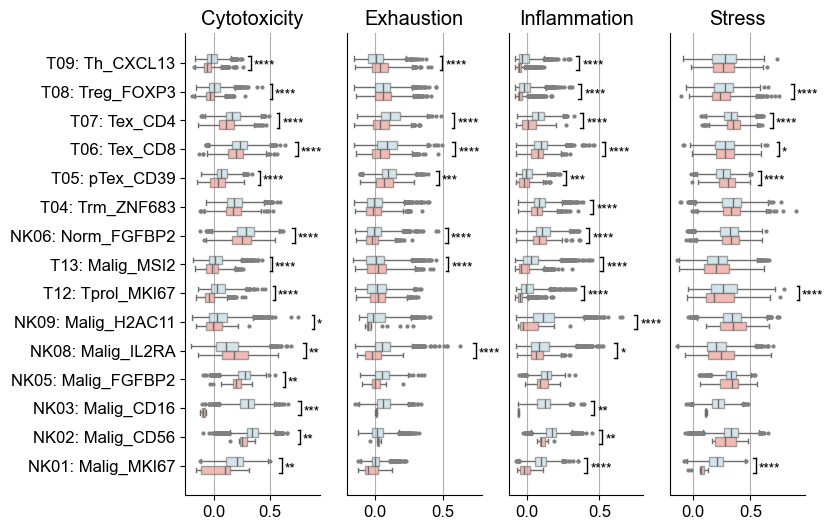

In [ ]:
# ---------------------------------------------------------
# Visualize functional score differences (Pre vs. Post ICI)
# ---------------------------------------------------------
# This section generates the boxplots comparing functional 
# module scores (cytotoxicity, exhaustion, inflammation, stress) 
# across specific T and NK cell subsets before and after ICI treatment. 
# It combines the T and NK metadata, filters for relevant treatment 
# groups, and defines a custom ordering for the cell types. A 
# statistical significance annotation function is defined to label 
# p-values from Mann-Whitney U tests directly on the plots. The 
# final figure displays horizontal boxplots with significance stars 
# and custom formatting, saving the output as a PDF.
# ---------------------------------------------------------
Tdf_T = adata_T.obs[['cytotoxicity', 'exhaustion', 'inflammation', 'stress', 'CellStateLabels', 'treatment']]
Tdf_NK = adata_NK.obs[['cytotoxicity', 'exhaustion', 'inflammation', 'stress', 'CellStateLabels', 'treatment']]
Tdf = pd.concat([Tdf_T, Tdf_NK], axis=0)
Tdf = Tdf[Tdf['treatment'].isin(['Pre', 'Post'])]
order = ['NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16', 'NK05: Malig_FGFBP2',
  'NK08: Malig_IL2RA', 'NK09: Malig_H2AC11', 'T12: Tprol_MKI67', 'T13: Malig_MSI2',
  'NK06: Norm_FGFBP2', 'T04: Trm_ZNF683', 'T05: pTex_CD39', 'T06: Tex_CD8', 
  'T07: Tex_CD4', 'T08: Treg_FOXP3', 'T09: Th_CXCL13']
order.reverse()
def get_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"
    
fig, ax = plt.subplots(1, 4, figsize=(8, 6))
flierprops = dict(markerfacecolor='grey', marker='.', markersize=4, linestyle='none', markeredgecolor='grey')
for i, x in enumerate(['cytotoxicity', 'exhaustion', 'inflammation', 'stress']):
  # 1. show the boxplot
  sns.boxplot(Tdf, x=x, y='CellStateLabels', orient='h', hue='treatment',order=order, boxprops=dict(alpha=0.6),
              palette=['lightblue', 'salmon'], width=0.6,ax=ax[i], flierprops=flierprops, showfliers=True)
  # annotate the p-values
  ytick_labels = [item.get_text() for item in ax[i].get_yticklabels()]
    
  for idx, cell_type in enumerate(ytick_labels):
    # extract pre and post data
    pre_data = Tdf[(Tdf['CellStateLabels'] == cell_type) & (Tdf['treatment'] == 'Pre')][x]
    post_data = Tdf[(Tdf['CellStateLabels'] == cell_type) & (Tdf['treatment'] == 'Post')][x]
    if len(pre_data) > 0 and len(post_data) > 0:
      stat, p = mannwhitneyu(pre_data, post_data, alternative='two-sided')
      star = get_star(p) 
      if p < 0.05: 
        current_data = Tdf[Tdf['CellStateLabels'] == cell_type][x]
        x_max_val = current_data.max()
        x_range = current_data.max() - current_data.min()
        x_pos = x_max_val + x_range * 0.15 
        y_pos = idx + 0.75 
        line_width = 1.5
        y_coord = idx 
        line_len = 0.25
        ax[i].plot([x_pos, x_pos], [y_coord- line_len, y_coord + line_len], color='black', linewidth=1)
        ax[i].plot([x_pos-0.02, x_pos], [y_coord-line_len, y_coord-line_len], color='black', linewidth=1)
        ax[i].plot([x_pos-0.02, x_pos], [y_coord+line_len, y_coord+line_len], color='black', linewidth=1)
        ax[i].text(x_pos + line_len*0.1, y_coord+1.5*line_len, star, 
                    ha='left', va='bottom', color='black', fontsize=10)
  if i > 0:
    ax[i].set_yticklabels([])
    ax[i].tick_params(axis='y', length=0)
  else:
    ax[i].set_yticklabels(order)
  ax[i].set_xlabel('')
  x_min, x_max = ax[i].get_xlim()
  start = np.ceil(x_min *2) / 2
  xticks = np.arange(start, x_max, 0.5)
  ax[i].set_xticks(xticks)
  ax[i].xaxis.grid(True)
  ax[i].legend_.set_visible(False)
  ax[i].spines['top'].set_visible(False)
  ax[i].spines['right'].set_visible(False)
  ax[i].set_ylabel('')
  ax[i].set_title(x.capitalize())
fig.savefig(f"{figPath}/Fig4c.pdf", bbox_inches='tight')

#### **Fig. 4d** Scatter plots depicting the differential expression of genes in Th following immune checkpoint inhibitor (ICI) therapy.

In [ ]:
# ---------------------------------------------------------
# Differential Expression Analysis using Memento (1D)
# ---------------------------------------------------------
# This function performs differential expression analysis 
# between two groups of cells using the Memento framework. 
# It subsets the input AnnData object based on the specified 
# cell types, prepares the data by setting up Memento with 
# a capture rate, and defines the treatment groups. It then 
# computes the 1D moments, sets up the statistical model 
# with a covariate and treatment variable, and runs the 
# hypothesis testing. The function returns the resulting 
# differential expression statistics.
# ---------------------------------------------------------
import memento
def DE_memento_1d(adata: ad.AnnData, ctleft: list, ctright: list, groupby='annotation'):
  _adata = adata[adata.obs[groupby].isin(ctleft + ctright)].copy()
  _adata = ad.AnnData(_adata.layers['Raw'], obs = _adata.obs, var = _adata.var)
  _adata.obs['stim'] = _adata.obs[groupby].isin(ctright)
  _adata.obs['stim'] = _adata.obs['stim'].astype('int')
  _adata.obs['capture_rate'] = 0.07
  memento.setup_memento(_adata, q_column='capture_rate')
  memento.create_groups(_adata, label_columns=['stim'])
  memento.compute_1d_moments(_adata, min_perc_group=.7)
  meta_df = memento.get_groups(_adata)
  meta_df['intercept'] = 1
  convariate = meta_df[['intercept']]
  treatment = (meta_df[['stim']] == 1).astype(float)
  
  memento.ht_1d_moments(_adata,
  covariate=convariate,
  treatment=treatment,
  num_cpus=16,
  resample_rep=False,
  )
  memento_results = memento.get_1d_ht_result(_adata)
  return(memento_results)

In [821]:
# ---------------------------------------------------------
# 2D Differential Expression Scatter Plot with Label Adjustment
# ---------------------------------------------------------
# This function generates a 2D scatter plot to visualize 
# differential expression results from two different comparisons 
# (e.g., cell type specificity vs. treatment response). It 
# identifies significant genes based on coefficient and p-value 
# thresholds, mapping significance to color and point size. 
# Crucially, it uses the `adjustText` library to automatically 
# adjust gene labels and prevent overlap, ensuring readability. 
# The plot includes reference lines for significance cutoffs 
# and a custom legend for point sizes.
# ---------------------------------------------------------
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import adjustText as adjust

def DEplot_2D(deg_anno:pd.DataFrame, deg_treat:pd.DataFrame, coef=0.5, c='coolwarm'):
    # Define a helper function to map p-values to point sizes for the legend
    def calculate_size(p):
        min_p = 1e-20
        max_p = 1e-5
        min_size = 30
        max_size = 120
        return ((p - min_p) / (max_p - min_p)) * (max_size - min_size) + min_size

    # Identify genes present in both input dataframes to ensure consistent plotting
    genes = list(set(deg_anno['gene']).intersection(deg_treat['gene']))
    # Create copies of the input dataframes to avoid modifying the originals
    anno_df = deg_anno.copy()
    treat_df = deg_treat.copy()
    # Filter dataframes to include only the common genes
    anno_df = anno_df[anno_df['gene'].isin(genes)]
    # Set gene as the index for easier alignment
    anno_df.index = anno_df['gene']
    # Add suffix to column names to distinguish from the other dataframe
    anno_df.columns = [s + '_anno' for s in anno_df.columns]
    # Filter and process the second dataframe similarly
    treat_df = treat_df[treat_df['gene'].isin(genes)]
    treat_df.index = treat_df['gene']
    treat_df.columns = [s + '_treat' for s in treat_df.columns]
    # Concatenate the two dataframes along the columns (axis=1)
    df = pd.concat([anno_df, treat_df], axis=1)

    # Initialize lists to store visual properties for each point
    colors = []
    sizes = []
    alphas = []
    color_values = []

    # Iterate through each gene to determine its visual representation
    for i in range(len(df)):
        # Check if the gene is NOT significant in either comparison
        if -coef < df['de_coef_anno'][i] < coef or \
            -coef < df['de_coef_treat'][i] < coef or \
            df['de_pval_anno'][i] > 1e-5 or \
            df['de_pval_treat'][i] > 1e-5:
            # Assign gray color, small size, and low alpha for non-significant genes
            sizes.append(20)
            alphas.append(0.3)
            colors.append('gray')
        else:
            # For significant genes, use the coefficient from the 'anno' comparison for color
            combined_value = df['de_coef_anno'][i]
            color_values.append(combined_value)
            colors.append(None)  # Placeholder to be filled later with colormap color
            # Size is based on the p-value from the 'treat' comparison
            sizes.append(calculate_size(df['de_pval_treat'][i]))
            alphas.append(1)

    # Create a color normalization object based on the range of coefficient values
    norm = Normalize(vmin=min(color_values), vmax=max(color_values))
    # Get the specified colormap
    cmap = plt.get_cmap(c)

    # Replace None placeholders in the colors list with actual colors from the colormap
    color_index = 0
    for i, color in enumerate(colors):
        if color is None:
            colors[i] = cmap(norm(color_values[color_index]))
            color_index += 1
    # Store the final colors in the dataframe
    df['sig'] = colors

    # Create the scatter plot using seaborn
    ax = sns.scatterplot(df,
                     x='de_coef_anno',
                     y='de_coef_treat',
                     color=colors,
                     s=sizes,
                     alpha=alphas,
                     zorder=0)

    # --- Label Addition and Adjustment ---
    # Initialize a list to hold text objects for adjustment
    texts = []
    # Iterate through points to add labels only for significant genes (colored points)
    for i, color in enumerate(colors):
        if isinstance(color, tuple):  # Check if the color is an RGBA tuple (significant)
            # Add a text label at the point's coordinates
            text = ax.text(
                df['de_coef_anno'][i],
                df['de_coef_treat'][i],
                df['gene_anno'][i],
                ha='center',
                va='center',
                fontsize=9,
                zorder=10
            )
            texts.append(text)

    # Use adjust_text to automatically reposition labels and minimize overlap
    # Arrows are added to connect labels to their original points
    adjust.adjust_text(texts,
                       arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                       ax=ax)
    # --- End of Label Adjustment ---

    # Add dashed reference lines at the significance coefficient thresholds
    ax.axvline(x=coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axvline(x=-coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axhline(y=coef, linestyle='--', color='black', zorder=3, linewidth=0.5)
    ax.axhline(y=-coef, linestyle='--', color='black', zorder=3, linewidth=0.5)

    # Reposition the spines to pass through the origin (0,0)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    # Hide the top and right spines
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    # Set the axis limits
    ax.set_xlim(-2.5, 1.7)
    ax.set_ylim(-1.8, 1.8)
    # Set custom tick locations
    ax.set_xticks([-1.5, -1, -0.5, 0.5, 1, 1.5])
    ax.set_yticks([-1.5, -1, -0.5, 0.5, 1, 1.5])
    # Ensure ticks are visible by setting their z-order
    for tick in ax.get_xticklines() + ax.get_yticklines():
        tick.set_zorder(10)
    # Ensure tick labels are visible
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_zorder(10)
    # Remove axis labels
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Create custom legend elements for point sizes
    size_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='50', markerfacecolor='black', markersize=np.sqrt(50)),
        Line2D([0], [0], marker='o', color='w', label='10', markerfacecolor='black', markersize=np.sqrt(30)),
        Line2D([0], [0], marker='o', color='w', label='No sig', markerfacecolor='black', markersize=np.sqrt(20))
    ]
    # Add the size legend to the plot
    first_legend = ax.legend(handles=size_legend_elements, loc='upper left', title='nelogP-value')
    ax.add_artist(first_legend)
    # Set the figure size
    ax.figure.set_size_inches(5, 4.5)
    return df, ax

In [823]:
# ---------------------------------------------------------
# Differential Expression Analysis for Th_CXCL13 cells
# ---------------------------------------------------------
# This section performs two distinct differential expression 
# analyses focusing on the T09: Th_CXCL13 cell population using 
# the previously defined DE_memento_1d function.
#
# 1. Cell Type Specificity Analysis:
#    The first analysis identifies genes that are specifically 
#    enriched in T09: Th_CXCL13 cells compared to other T cell 
#    subsets (Treg, Tn/Tcm, and Tctl). This establishes the 
#    unique transcriptional identity of the Th_CXCL13 population.
#
# 2. Treatment Response Analysis:
#    The second analysis investigates the effect of ICI therapy 
#    on the T09: Th_CXCL13 cells. It compares the gene expression 
#    profiles of these cells before (Pre) and after (Post) treatment 
#    to identify therapy-induced transcriptional changes.
# ---------------------------------------------------------
ctleft = ['T08: Treg_FOXP3', 'T10: Tn/Tcm_IL7R', 'T11: Tctl_GZMK']
ctright = ['T09: Th_CXCL13']
Th_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='CellStateLabels')
ctleft = ['Pre']
ctright = ['Post']
Th_treat_degs = DE_memento_1d(adata_T[adata_T.obs['CellStateLabels'].isin(['T09: Th_CXCL13'])], 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='treatment')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    6.7s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    9.9s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:   14.4s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   19.2s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:   25.7s
[Parallel(n_jobs=16)]: Done 3168 tasks      | elapsed:   32.7s
[Parallel(n_jobs=16)]: Done 4018 tasks      | elapsed:   40.7s
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed:   49.7s
[Parallel(n_jobs=16)]: Done 6018 tasks      | elapsed:   59.2s
[Parallel(n_jobs=16)]: Done 6747 out of 6747 | elapsed:  1.1min finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]:

/tmp/ipykernel_3335451/2177587855.py:58: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:59: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

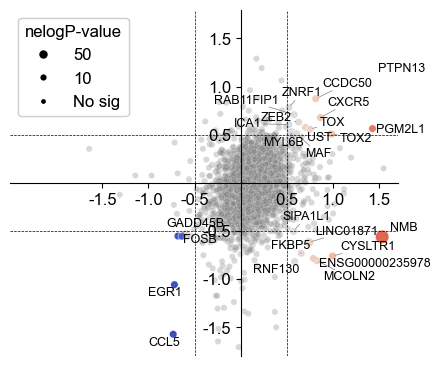

In [824]:
Th_df, Th_ax = DEplot_2D(Th_degs, Th_treat_degs)
Th_ax.figure.savefig(f"{figPath}/Fig4d.pdf", bbox_inches='tight')

#### **Fig. 4e** Scatter plots depicting the differential expression of genes in Tregs following immune checkpoint inhibitor (ICI) therapy.

In [ ]:
# ---------------------------------------------------------
# Differential Expression Analysis for Treg_FOXP3 cells
# ---------------------------------------------------------
# This section performs two differential expression analyses 
# focusing on the T08: Treg_FOXP3 cell population using the 
# DE_memento_1d function.
#
# 1. Cell Type Specificity Analysis:
#    The first analysis identifies genes specifically enriched 
#    in T08: Treg_FOXP3 cells compared to other T cell subsets 
#    (Th_CXCL13, Tn/Tcm, and Tctl). This defines the unique 
#    transcriptional signature of the Treg population.
#
# 2. Treatment Response Analysis:
#    The second analysis examines the impact of ICI therapy on 
#    T08: Treg_FOXP3 cells by comparing their gene expression 
#    profiles before (Pre) and after (Post) treatment. This 
#    reveals therapy-associated transcriptional changes within 
#    the Treg compartment.
# ---------------------------------------------------------
ctleft = [ 'T09: Th_CXCL13', 'T10: Tn/Tcm_IL7R', 'T11: Tctl_GZMK']
ctright = ['T08: Treg_FOXP3']
Treg_anno_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='CellStateLabels')
ctleft = ['Pre']
ctright = ['Post']
Treg_degs = DE_memento_1d(adata_T[adata_T.obs['CellStateLabels'] == 'T08: Treg_FOXP3'], 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='treatment')

/tmp/ipykernel_3335451/2177587855.py:58: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:59: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

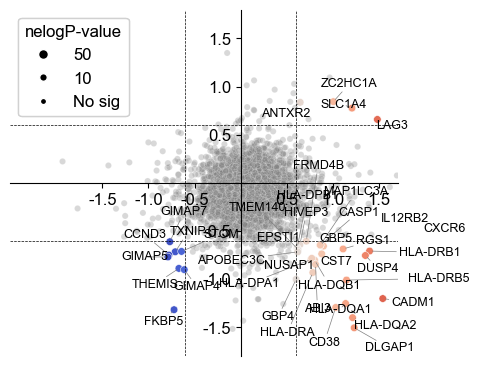

In [825]:
Treg_df, Treg_ax = DEplot_2D(Treg_anno_degs, Treg_degs, coef=0.6)
Treg_ax.figure.savefig(f"{figPath}/Fig4e.pdf", bbox_inches='tight')

#### **Fig. 4f** Scatter plots depicting the differential expression of genes in Tex following immune checkpoint inhibitor (ICI) therapy.

In [ ]:
# ---------------------------------------------------------
# Differential Expression Analysis for Exhausted T (Tex) Cells
# ---------------------------------------------------------
# This section performs two differential expression analyses 
# focusing on the exhausted T cell populations (T05: pTex_CD39, 
# T06: Tex_CD8, T07: Tex_CD4) using the DE_memento_1d function.
#
# 1. Cell Type Specificity Analysis:
#    The first analysis identifies genes specifically enriched 
#    in exhausted T cells (Tex) compared to naive and memory 
#    T cell subsets (Tn, Tcm, Trm). This defines the unique 
#    transcriptional signature associated with T cell exhaustion.
#
# 2. Treatment Response Analysis:
#    The second analysis examines the impact of ICI therapy on 
#    the exhausted T cell compartment by comparing gene expression 
#    profiles before (Pre) and after (Post) treatment. This reveals 
#    therapy-induced transcriptional reprogramming within Tex populations.
# ---------------------------------------------------------
ctleft = ['T01: Tn_CCR7', 'T02: Tcm_SELL', 'T03: Tcm_XCL1', 'T04: Trm_ZNF683']
ctright = [ 'T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4']
Tex_anno_degs = DE_memento_1d(adata_T, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='CellStateLabels')
ctleft = ['Pre']
ctright = ['Post']
Tex_degs = DE_memento_1d(adata_T[adata_T.obs['CellStateLabels'].isin(['T05: pTex_CD39', 'T06: Tex_CD8', 'T07: Tex_CD4'])], 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='treatment')

/tmp/ipykernel_3335451/2177587855.py:58: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:59: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

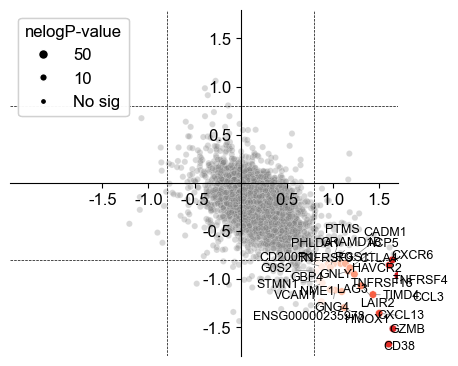

In [826]:
Tex_df, Tex_ax = DEplot_2D(Tex_anno_degs, Tex_degs, coef=0.8, c='Reds')
Tex_ax.figure.savefig(f"{figPath}/Fig2f.pdf", bbox_inches='tight')

#### **Fig. 4g** Scatter plots depicting the differential expression of genes in NKT following immune checkpoint inhibitor (ICI) therapy.

In [828]:
adata_NK.obs['CellStateLabels'].cat.categories

Index(['NK01: Malig_MKI67', 'NK02: Malig_CD56', 'NK03: Malig_CD16',
       'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2', 'NK06: Norm_FGFBP2',
       'NK07: Norm_KIT', 'NK08: Malig_IL2RA', 'NK09: Malig_H2AC11'],
      dtype='object')

In [829]:
ctleft = ['C01_NK_MKI67', 'C02_NK_CD56', 'C03_NK_CD16', 'C04_NK_CD200R1',
       'C06_NK_KIT', 'C07_Malig_IL2RA', 'C08_Malig_H2AC11']
ctright = [ 'C05_NKT_FGFBP2']
NKT_anno_degs = DE_memento_1d(adata_NK, 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='anno-NK')
ctleft = ['Pre']
ctright = ['Post']
NKT_degs = DE_memento_1d(adata_NK[adata_NK.obs['CellStateLabels'].isin(['NK05: Malig_FGFBP2', 'NK06: Norm_FGFBP2'])], 
                         ctleft = ctleft, 
                         ctright = ctright, 
                         groupby='treatment')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    4.7s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    7.9s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:   12.5s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:   18.2s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:   25.0s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:   32.9s
[Parallel(n_jobs=16)]: Done 3168 tasks      | elapsed:   43.1s
[Parallel(n_jobs=16)]: Done 4018 tasks      | elapsed:   53.2s
[Parallel(n_jobs=16)]: Done 4968 tasks      | elapsed:  1.1min
[Parallel(n_jobs=16)]: Done 6018 tasks      | elapsed:  1.3min
[Parallel(n_jobs=16)]: Done 7168 tasks      | elapsed:  1.5min
[Parallel(n_jobs=16)]: Done 7990 out of 7990 | elapsed:  1.7min finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]

/tmp/ipykernel_3335451/2177587855.py:58: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:59: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3335451/2177587855.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

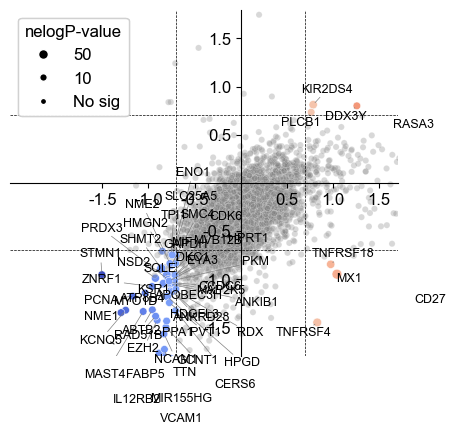

In [830]:
NKT_df, NKT_ax = DEplot_2D(NKT_anno_degs, NKT_degs,coef=0.7)
NKT_ax.figure.savefig(f"{figPath}/Fig2g.pdf", bbox_inches='tight')

#### **Fig. 2h** The top 10 enrichment pathways of pre-ICI versus post-ICI samples in pTex, CD8+ Tex, Treg, and FGFBP2+ NKT cells revealed by MSigDB HallMark 2020. 
The dot size represents the proportion of highly expressed genes in the predefined gene sets. The color of the dots represents the negative log10 Benjamini–Hochberg FDR.

In [831]:
import gseapy as gp
from gseapy import Msigdb

def prep_enrichr(adata, groupby):
  """
  Prepares differential expression results for enrichment analysis.
  
  This function performs differential expression analysis using Scanpy's 
  rank_genes_groups method and organizes the results into a structured 
  DataFrame. It extracts gene names, scores, p-values, and log fold changes 
  for all groups, formatting them for downstream enrichment analysis.
  
  Parameters:
  -----------
  adata : AnnData
      The annotated AnnData object containing the single-cell data.
  groupby : str
      The key in adata.obs that defines the groups for comparison.
      
  Returns:
  --------
  pandas.DataFrame
      A DataFrame containing differential expression results with columns 
      formatted as 'group_key' (e.g., 'cluster_names', 'cluster_pvals').
  """
  # de analysis
  sc.tl.rank_genes_groups(adata, groupby=groupby)
  sc.tl.dendrogram(adata, groupby=groupby)
  # get deg result
  result = adata.uns['rank_genes_groups']
  groups = result['names'].dtype.names
  degs = pd.DataFrame(
      {group + '_' + key: result[key][group]
      for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
  return degs

def run_enrichr_genelist(genelist):
  """
  Performs enrichment analysis on a list of genes using multiple databases.
  
  This function runs enrichment analysis on the provided gene list using 
  five different gene set libraries: KEGG pathways, GO Cellular Component, 
  MSigDB Hallmark, GO Molecular Function, and GO Biological Process. It 
  returns the results from all five analyses for comprehensive functional 
  annotation.
  
  Parameters:
  -----------
  genelist : list
      A list of gene symbols to be analyzed for enrichment.
      
  Returns:
  --------
  tuple
      A tuple containing five enrichment result objects (KEGG, Cellular 
      Component, Hallmark, Molecular Function, Biological Process).
  """
  kegg = gp.enrichr(genelist,
                  gene_sets='KEGG_2021_Human',
                  outdir=None)
  cc = gp.enrichr(genelist,
                      gene_sets='GO_Cellular_Component_2023',
                      outdir=None)
  hm = gp.enrichr(genelist,
                      gene_sets=['MSigDB_Hallmark_2020'],
                      outdir=None)
  mf = gp.enrichr(genelist,
                      gene_sets='GO_Molecular_Function_2023',
                      outdir=None)
  bp = gp.enrichr(genelist,
                      gene_sets=['GO_Biological_Process_2023'],
                      outdir=None)
  return kegg, cc, hm, mf, bp

def run_enrichr_scanpy(degs, group,direction='up', top_term=15, all_term=False, plot=True):
  """
  Performs enrichment analysis on Scanpy differential expression results.
  
  This function filters differentially expressed genes based on adjusted 
  p-value and log fold change, then performs enrichment analysis on either 
  up-regulated or down-regulated genes. It combines results from multiple 
  databases and optionally generates a bar plot of the top enriched terms.
  
  Parameters:
  -----------
  degs : pandas.DataFrame
      DataFrame containing differential expression results from prep_enrichr.
  group : str
      The group name to analyze (e.g., 'cluster_0').
  direction : str, optional
      Either 'up' or 'down' to specify direction of regulation.
  top_term : int, optional
      Number of top enriched terms to display in the plot.
  all_term : bool, optional
      If True, returns all enriched terms instead of just the top ones.
  plot : bool, optional
      If True, generates a bar plot of enriched terms.
      
  Returns:
  --------
  tuple
      A tuple containing the enrichment results DataFrame and the plot axis 
      (or None if plot=False).
  """
  # subset up or down regulated genes
  degs_sig = degs[degs[f'{group}_pvals_adj'] < 0.05]
  degs_up = degs_sig[degs_sig[f'{group}_logfoldchanges'] > 0]
  degs_dw = degs_sig[degs_sig[f'{group}_logfoldchanges'] < 0]
  degs_used = degs_up[f'{group}_names'] if direction == 'up' else degs_dw[f'{group}_names']
  kegg, cc, hm, mf, bp = run_enrichr_genelist(degs_used)
  go_res = pd.concat([kegg.res2d.head(top_term),
                    hm.res2d.head(top_term), 
                    cc.res2d.head(top_term), 
                    bp.res2d.head(top_term), 
                    mf.res2d.head(top_term)])
  if plot:
    ax = gp.barplot(go_res, figsize=(6,20),
                group ='Gene_set',
                top_term=top_term,
                color = ['#8b9cc4', '#f08961', '#62bb9f', '#e71f19', '#3d5eaa'],
                title ="The Most Enriched Terms")
  else:
    ax = None
  if all_term:
    go_res = pd.concat([kegg.res2d, hm.res2d, cc.res2d, bp.res2d, mf.res2d])
  return go_res, ax
  
def run_enrichr_memento(memento_results,direction='up', top_term=15):
  """
  Performs enrichment analysis on Memento differential expression results.
  
  This function filters differentially expressed genes from Memento results 
  based on p-value and coefficient, then performs enrichment analysis on 
  either up-regulated or down-regulated genes. It combines results from 
  multiple databases and generates a bar plot of the top enriched terms.
  
  Parameters:
  -----------
  memento_results : pandas.DataFrame
      DataFrame containing differential expression results from Memento.
  direction : str, optional
      Either 'up' or 'down' to specify direction of regulation.
  top_term : int, optional
      Number of top enriched terms to display in the plot.
      
  Returns:
  --------
  tuple
      A tuple containing the enrichment results DataFrame and the plot axis.
  """
  memento_sig = memento_results[memento_results['de_pval'] < 0.05]
  memento_up = memento_sig[memento_sig['de_coef'] > 0]
  memento_dw = memento_sig[memento_sig['de_coef'] < 0]
  degs_used = memento_up['gene'] if direction == 'up' else memento_dw['gene']
  kegg, cc, hm, mf, bp = run_enrichr_genelist(degs_used)
  go_res = pd.concat([kegg.res2d.head(15),
                      hm.res2d.head(15), 
                      cc.res2d.head(15), 
                      bp.res2d.head(15), 
                      mf.res2d.head(15)])
  ax = gp.barplot(go_res, figsize=(6,20),
              group ='Gene_set',
              top_term=top_term,
              color = ['#8b9cc4', '#f08961', '#62bb9f', '#e71f19', '#3d5eaa'],
              title ="The Most Enriched Terms")
  return go_res, ax

In [834]:
def HallMarkPlot(adata, anno, left, right, ct, left_label='Pre-ICI', right_label='Post-ICI', title=None):
  """
  Generates a comparative dot plot for Hallmark pathways between two treatment groups.
  
  This function performs enrichment analysis on two subsets of data (e.g., Pre-ICI 
  vs. Post-ICI) for a specific cell type. It identifies the top Hallmark pathways 
  enriched in each group, finds the intersection of these pathways, and visualizes 
  the enrichment status (significance and gene ratio) using a dot plot. This allows 
  for a direct visual comparison of how specific biological programs change between 
  conditions.
  
  Parameters:
  -----------
  adata : AnnData
      The input AnnData object containing the single-cell data.
  anno : str
      The key in adata.obs used for grouping (e.g., 'CellStateLabels').
  left : list
      List of treatment labels for the first group (e.g., ['Pre']).
  right : list
      List of treatment labels for the second group (e.g., ['Post']).
  ct : str
      The specific cell type/cluster label to analyze (e.g., 'T09: Th_CXCL13').
  left_label : str, optional
      Label for the x-axis corresponding to the 'left' group.
  right_label : str, optional
      Label for the x-axis corresponding to the 'right' group.
  title : str, optional
      Custom title for the plot. If None, the cell type 'ct' is used.
      
  Returns:
  --------
  tuple
      A tuple containing the filtered DataFrame with pathway enrichment results 
      and the matplotlib axis object for the generated dot plot.
  """
  degs_pre = prep_enrichr(adata[adata.obs['treatment'].isin(left)], anno)
  degs_post = prep_enrichr(adata[adata.obs['treatment'].isin(right) ], anno)
  print(f"Running enrichment for {left_label} {ct}...")
  go_pre, _ = run_enrichr_scanpy(degs_pre, ct,direction='up', top_term=15, all_term=True, plot=False)
  go_pre =  go_pre[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']]
  go_pre['anno'] = ct
  go_pre['treatment'] = 'left'

  print(f"Running enrichment for {right_label} {ct}...")
  go_post, _ = run_enrichr_scanpy(degs_post, ct,direction='up', top_term=15, all_term=True, plot=False)
  go_post = go_post[['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']]
  go_post['anno'] = ct
  go_post['treatment'] = 'right'

  left_pathway = go_pre[go_pre['Gene_set'].isin(['MSigDB_Hallmark_2020'])][:10]['Term']
  right_pathway = go_post[go_post['Gene_set'].isin(['MSigDB_Hallmark_2020'])][:10]['Term']
  pathway = list(set(list(left_pathway)).intersection(list(right_pathway)))

  use_pathway_left = go_pre[go_pre['Gene_set'].isin(['MSigDB_Hallmark_2020'])]
  use_pathway_right = go_post[go_post['Gene_set'].isin(['MSigDB_Hallmark_2020'])]

  use_pathway_left = use_pathway_left[use_pathway_left['Term'].isin(left_pathway)]
  use_pathway_right = use_pathway_right[use_pathway_right['Term'].isin(right_pathway)]
  use_pathway = pd.concat([use_pathway_left, use_pathway_right], axis=0)
  ax = gp.dotplot(use_pathway,figsize=(2,5),
                x='treatment',
                title="",
                size=2.5,
                cmap='viridis',
                top_term=10,
                show_ring=True)
  ax.set_xticklabels(['Pre-ICI', 'Post-ICI'],rotation=0)
  ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=11)
  ax.set_xlabel('')
  if title is None:
    ax.set_title(ct)
  else:
    ax.set_title(title)
  return use_pathway, ax

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T04: Trm_ZNF683...
Running enrichment for Post-ICI T04: Trm_ZNF683...


/home/rzh/miniconda3/lib/python3.11/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



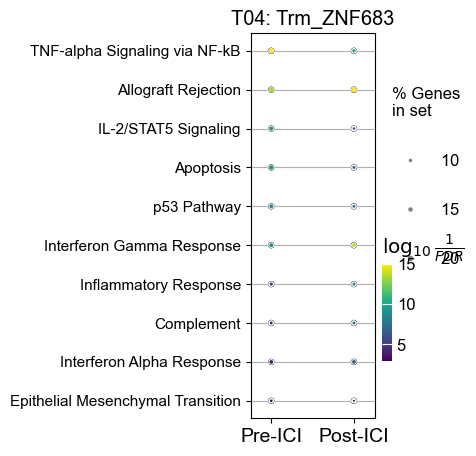

In [ ]:
use_pathway_Trm, ax_Trm = HallMarkPlot(adata_CD8T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T04: Trm_ZNF683', title='T04: Trm_ZNF683')
ax_Trm.figure.savefig(f"{figPath}/Fig4h-Trm.pdf", bbox_inches='tight')

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T05: pTex_CD39...
Running enrichment for Post-ICI T05: pTex_CD39...


/home/rzh/miniconda3/lib/python3.11/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



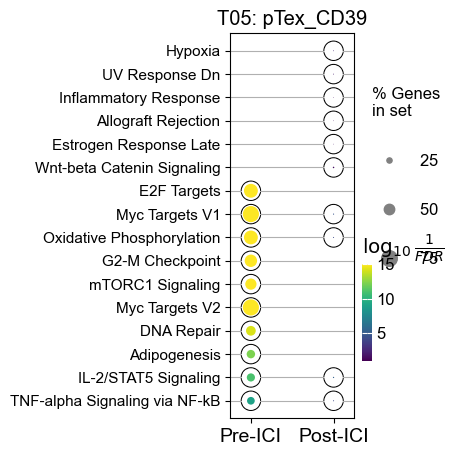

In [838]:
use_pathway_pTex, ax_pTex = HallMarkPlot(adata_CD8T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T05: pTex_CD39', title='T05: pTex_CD39')
ax_pTex.figure.savefig(f"{figPath}/Fig4h-pTex.pdf", bbox_inches='tight')

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T06: Tex_CD8...
Running enrichment for Post-ICI T06: Tex_CD8...


/home/rzh/miniconda3/lib/python3.11/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



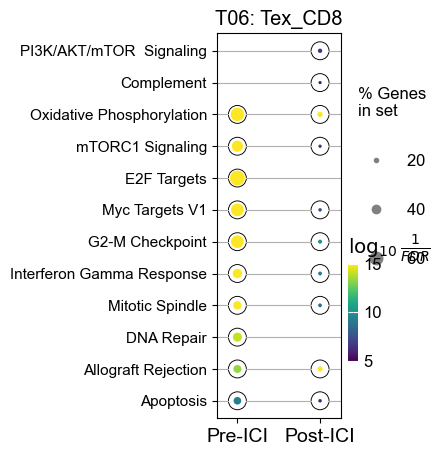

In [839]:
use_pathway_Tex, ax_Tex = HallMarkPlot(adata_CD8T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T06: Tex_CD8', title='T06: Tex_CD8')
ax_Tex.figure.savefig(f"{figPath}/Fig4h-Tex.pdf", bbox_inches='tight')

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.

/home/rzh/miniconda3/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Running enrichment for Pre-ICI T08: Treg_FOXP3...
Running enrichment for Post-ICI T08: Treg_FOXP3...


/home/rzh/miniconda3/lib/python3.11/site-packages/gseapy/plot.py:753: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_3335451/2941434295.py:68: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3335451/2941434295.py:69: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



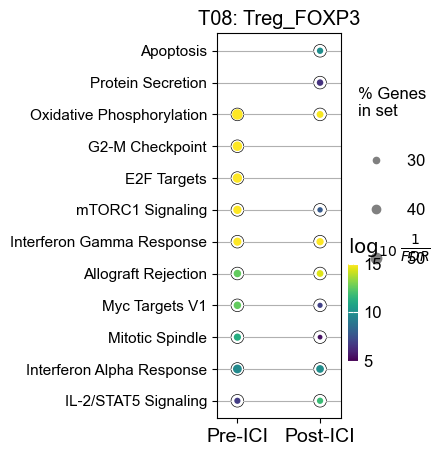

In [840]:
use_pathway_Treg, ax_Treg = HallMarkPlot(adata_CD4T, 'CellStateLabels', ['Pre'], ['Post', 'PBMC'], 'T08: Treg_FOXP3', title='T08: Treg_FOXP3')
ax_Treg.figure.savefig(f"{figPath}/Fig4h-Treg.pdf", bbox_inches='tight')

#### **Table 7.** Pre- and post-therapy proportions and absolute counts of T/NK cell types and states, with statistical analysis.

In [842]:
from typing import List, Dict, Any
def calculate_cliffs_delta(group1: np.ndarray, group2: np.ndarray) -> float:
    """Calculate Cliff's Delta (Post vs Pre)"""
    n1, n2 = len(group1), len(group2)
    if n1 == 0 or n2 == 0: return 0.0
    diff = np.subtract.outer(group1, group2) 
    delta = (np.sum(diff > 0) - np.sum(diff < 0)) / (n1 * n2)
    return delta

def extract_stats_to_dataframe_onetailed(results_list: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    
    for res in results_list:
        # 1. extract Subset
        subset_name = res.get('target_labels', ['Unknown'])[0]
        n_cells_pre = res['cell_level']['contingency_table']['Target']['Pre']
        n_cells_post = res['cell_level']['contingency_table']['Target']['Post']
        
        # 2. extract Sample Level data
        sample_stats = res.get('sample_level', {})
        
        median_pre = sample_stats.get('median_pre', np.nan)
        median_post = sample_stats.get('median_post', np.nan)
        
        p_one = sample_stats.get('p_mwu_one_sided', np.nan)
        u_stat = sample_stats.get('u_stat', np.nan)
        pre_props = sample_stats.get('pre_props', np.array([]))
        post_props = sample_stats.get('post_props', np.array([]))
        
        # 3. Calculate Cliff's Delta
        effect_size = calculate_cliffs_delta(post_props, pre_props)
        
        # 4. P-value formatting
        if np.isnan(p_one):
            p_str = "N/A"
            sig_stars = ""
            is_sig = False
        else:
            # one side significance 0.05
            is_sig = p_one < 0.05
            
            if p_one < 0.001:
                p_str = "<0.001"
                sig_stars = "***"
            elif p_one < 0.01:
                p_str = f"{p_one:.3f}"
                sig_stars = "**"
            elif p_one < 0.05:
                p_str = f"{p_one:.2f}"
                sig_stars = "*"
            else:
                p_str = f"{p_one:.2f}"
                sig_stars = ""
            
        direction = ""
        icon = ""
        text = ""
        
        if not np.isnan(effect_size):
            if is_sig:
                if effect_size > 0:
                    direction, icon = "Increased", "⬆️"
                elif effect_size < 0:
                    direction, icon = "Decreased", "⬇️"
                else:
                    direction, icon = "Changed", "⚠️"
                text = f"{icon} {direction}"
            else:
                if abs(effect_size) < 0.1:
                    icon, text = "➖", "Stable"
                else:
                    if effect_size > 0:
                        icon, text = "↗️", "Trend (Increase)"
                    else:
                        icon, text = "↘️", "Trend (Decrease)"
        
        # 5. build stats_dict for detailed stats
        stats_dict = {
            'median_pre': float(median_pre) if not np.isnan(median_pre) else None,
            'median_post': float(median_post) if not np.isnan(median_post) else None,
            'p_value_one_sided': float(p_one) if not np.isnan(p_one) else None, # 只保留单侧
            'u_statistic': float(u_stat) if not np.isnan(u_stat) else None,
            'effect_size_cliffs_delta': float(effect_size),
            'n_pre': n_cells_pre,
            'n_post': n_cells_post,
            'n_cells_pre': n_cells_pre,
            'n_cells_post': n_cells_post,
            'pre_props_array': pre_props.tolist() if isinstance(pre_props, np.ndarray) else list(pre_props),
            'post_props_array': post_props.tolist() if isinstance(post_props, np.ndarray) else list(post_props)
        }
        
        # 6. build row for dataframe
        row = {
            'Subset': subset_name,
            'N_cells Pre': n_cells_pre,
            'N_cells Post': n_cells_post,
            'Median Pre (%)': f"{median_pre * 100:.1f}" if not np.isnan(median_pre) else "N/A",
            'Median Post (%)': f"{median_post * 100:.1f}" if not np.isnan(median_post) else "N/A",
            'P-value (One-sided)': f"{p_str}{sig_stars}", # 列名明确标注
            'Effect Size': f"{effect_size:.2f}",
            'Interpretation': text,
            'Stats_Dict': stats_dict
        }
        
        rows.append(row)
    
    return pd.DataFrame(rows)

In [841]:
def get_prop_tables(adata, anno_col, Denominator = "\% of Total Non-malignant Immune"):
  """
  Generates a comprehensive DataFrame of cell type proportions for all categories.
  
  This function iterates through every category present in the specified annotation 
  column. For each category, it calculates the differential proportion using 
  `compare_cell_type_proportion`, extracts the statistical results, and aggregates 
  them into a single master DataFrame. This allows for a consolidated view of 
  abundance changes across all cell types.
  
  Parameters:
  -----------
  adata : AnnData
      The input AnnData object containing the single-cell data.
  anno_col : str
      The column name in adata.obs containing the cell type annotations (e.g., 'CellStateLabels').
  Denominator : str, optional
      The reference group or description for the proportion calculation (default is 
      "% of Total Non-malignant Immune").
      
  Returns:
  --------
  pandas.DataFrame
      A concatenated DataFrame containing the proportion statistics for all cell types.
  """
  subset_list = adata.obs[anno_col].cat.categories
  prop_tables = pd.DataFrame()
  for subset in subset_list:
    result = compare_cell_type_proportion(
    adata=norm_immune,
    target_label=[subset],
    anno_col=anno_col,
    title_prefix=Denominator,
    plot=False
    )
    df_table = extract_stats_to_dataframe_onetailed([result])
    prop_tables = pd.concat([prop_tables, df_table])
  return prop_tables

In [843]:
prop_tables_major = get_prop_tables(norm_immune, "CellTypeLabels",  Denominator = "\% of Total Non-malignant Immune")
prop_tables_minor = get_prop_tables(norm_immune, "CellStateLabels",  Denominator = "\% of Total Non-malignant Immune")
display_cols = ['Subset', 'N_cells Pre', 'N_cells Post', 'Median Pre (%)',
       'Median Post (%)', 'P-value (One-sided)', 'Effect Size',
       'Interpretation', 'Stats_Dict']
prop_tables_major[display_cols].to_excel(f'{tablePath}/06_prop-major.xlsx', index=False)
prop_tables_minor[display_cols].to_excel(f'{tablePath}/07_prop-minor.xlsx', index=False)

=== Cell-level Analysis (All Cells) ===
Target cell type(s): CD4+ T
           Non-Target  Target
Treatment                    
Post             6851    7986
Pre             16352   10834

Fisher's exact test p-value: 1.660e-166
Proportion - Pre: 39.9%, Post: 53.8%

=== Sample-level Analysis (Per Sample) ===
Number of samples: Pre = 11, Post = 5
Mean proportion - Pre: 44.6%, Post: 57.0%
Median proportion - Pre: 44.2%, Post: 57.8%
Mann-Whitney U test (one-sided, Post > Pre): p = 0.057

=== Cell-level Analysis (All Cells) ===
Target cell type(s): CD8+ T
           Non-Target  Target
Treatment                    
Post             9072    5765
Pre             13305   13881

Fisher's exact test p-value: 1.213e-127
Proportion - Pre: 51.1%, Post: 38.9%

=== Sample-level Analysis (Per Sample) ===
Number of samples: Pre = 11, Post = 5
Mean proportion - Pre: 43.7%, Post: 33.8%
Median proportion - Pre: 45.1%, Post: 30.5%
Mann-Whitney U test (one-sided, Post > Pre): p = 0.927

=== Cell-level Analy

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas

=== Cell-level Analysis (All Cells) ===
Target cell type(s): T04: Trm_ZNF683
           Non-Target  Target
Treatment                    
Post            13674    1163
Pre             24465    2721

Fisher's exact test p-value: 1.276e-13
Proportion - Pre: 10.0%, Post: 7.8%

=== Sample-level Analysis (Per Sample) ===
Number of samples: Pre = 11, Post = 5
Mean proportion - Pre: 9.5%, Post: 8.3%
Median proportion - Pre: 8.4%, Post: 7.9%
Mann-Whitney U test (one-sided, Post > Pre): p = 0.629

=== Cell-level Analysis (All Cells) ===
Target cell type(s): T05: pTex_CD39
           Non-Target  Target
Treatment                    
Post            14715     122
Pre             26400     786

Fisher's exact test p-value: 7.385e-51
Proportion - Pre: 2.9%, Post: 0.8%

=== Sample-level Analysis (Per Sample) ===
Number of samples: Pre = 11, Post = 5
Mean proportion - Pre: 2.7%, Post: 0.6%
Median proportion - Pre: 2.7%, Post: 0.5%
Mann-Whitney U test (one-sided, Post > Pre): p = 0.986

=== Cell-level A

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3335451/610078828.py:109: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pas